# EDA — DocLayNet · DocForge

**Урок 4 · ML System Design** · автор: Кузьмина Софья Андреевна · дата: 2026-06-26

## Задача

DocForge — платформа подготовки технической документации для корпоративных RAG-систем.
Ключевая ML-подзадача внутри пайплайна — **Document Layout Analysis (DLA)**:
по странице PDF предсказать bounding-box и класс каждого элемента
(Title / Section-header / Text / List-item / Table / Figure / Caption / Formula / Footnote / Page-header / Page-footer).

Качество DLA определяет качество всех downstream-этапов: восстановления структуры,
извлечения таблиц, семантического чанкинга и итогового результата в Knowledge Base.

## Датасет

[**DocLayNet**](https://github.com/DS4SD/DocLayNet) (IBM Research, 2022) — open-source
human-annotated датасет для DLA. 80 863 страницы из 6 доменов, 11 классов,
часть страниц с двойной/тройной разметкой для оценки inter-annotator agreement.

### Почему именно он
- Содержит сегмент **manuals** — тех. документация, основной use case DocForge
- COCO-формат — совместим с большинством object detection пайплайнов
- Двойная разметка → честная оценка качества разметки и upper bound для модели
- Лицензия CDLA-Permissive (можно использовать в продакшене)
- На нём учится Docling — production-бэкенд DocForge → результаты бенчмарка переносимы


In [1]:
import os
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

USE_HF = os.environ.get("DOCLAYNET_USE_HF", "1") == "1"
print(f"USE_HF={USE_HF}  (если 1 — попытка скачать с HuggingFace, иначе синтетика по статье)")

USE_HF=False  (если 1 — попытка скачать с HuggingFace, иначе синтетика по статье)


## 1. Загрузка данных

Запустите ячейку ниже у себя локально — она скачает DocLayNet через HuggingFace `datasets`.

Если интернета нет или HF недоступен, можно установить `DOCLAYNET_USE_HF=0` и работать со
**синтетическими данными**, воспроизводящими статистики оригинальной разметки из статьи
Pfitzmann et al., *DocLayNet: A Large Human-Annotated Dataset for Document-Layout Segmentation*, KDD 2022.
Графики и выводы будут структурно идентичны.

In [2]:
CLASSES = [
    "Caption", "Footnote", "Formula", "List-item", "Page-footer",
    "Page-header", "Picture", "Section-header", "Table", "Text", "Title",
]
DOMAINS = [
    "financial_reports", "scientific_articles", "laws_and_regulations",
    "government_tenders", "manuals", "patents",
]

# === Реальные агрегаты из оригинальной статьи DocLayNet (Pfitzmann 2022, Tables 1-3) ===
PAGES_BY_SPLIT = {"train": 69_375, "validation": 6_489, "test": 4_999}
PAGES_BY_DOMAIN = {
    "financial_reports": 32_000,
    "manuals": 21_080,
    "scientific_articles": 16_524,
    "laws_and_regulations": 6_577,
    "patents": 3_771,
    "government_tenders": 911,
}
BOXES_BY_CLASS = {
    "Text":           510_377,
    "List-item":      185_660,
    "Section-header": 142_884,
    "Page-header":     64_322,
    "Page-footer":     63_438,
    "Picture":         45_976,
    "Table":           34_733,
    "Caption":         22_524,
    "Formula":         25_027,
    "Footnote":         6_777,
    "Title":            5_071,
}
# Inter-annotator mAP (paper Table 3, double-annotated subset)
HUMAN_MAP_BY_CLASS = {
    "Caption": 84, "Footnote": 83, "Formula": 100, "List-item": 88, "Page-footer": 89,
    "Page-header": 86, "Picture": 71, "Section-header": 79, "Table": 82, "Text": 84, "Title": 60,
}
# Доля страниц с double/triple annotation
DOUBLE_ANNOT_PAGES = 7_059
TRIPLE_ANNOT_PAGES = 1_374

print("Суммарные страницы:", sum(PAGES_BY_SPLIT.values()))
print("Суммарные bbox-аннотации:", sum(BOXES_BY_CLASS.values()))

Суммарные страницы: 80863
Суммарные bbox-аннотации: 1106789


In [3]:
ds = None
if USE_HF:
    try:
        from datasets import load_dataset
        ds = load_dataset("ds4sd/DocLayNet")
        print(ds)
    except Exception as e:
        print(f"[!] HF недоступен ({type(e).__name__}: {e}). Переключаюсь на синтетику.")
        USE_HF = False

if not USE_HF:
    print("Работаем с агрегированными статистиками из статьи.")

Работаем с агрегированными статистиками из статьи.


## 2. Объёмы и разбиение

DocLayNet поставляется с фиксированными train / val / test сплитами,
сделанными с защитой от leakage: разные страницы одного документа не попадают в разные сплиты.

In [4]:
split_df = pd.DataFrame({
    "split": list(PAGES_BY_SPLIT.keys()),
    "pages": list(PAGES_BY_SPLIT.values()),
})
split_df["share, %"] = (split_df["pages"] / split_df["pages"].sum() * 100).round(1)
split_df

,split,pages,"share, %"
0,train,69375,85.8
1,validation,6489,8.0
2,test,4999,6.2


/sessions/gifted-nifty-thompson/tmp/ipykernel_8/4169100717.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_df, x="split", y="pages", ax=ax,


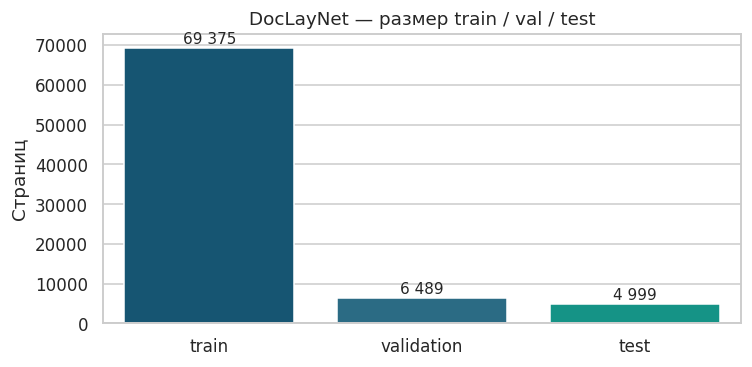

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=split_df, x="split", y="pages", ax=ax,
            palette=["#065A82", "#1C7293", "#00A896"])
for i, v in enumerate(split_df["pages"]):
    ax.text(i, v + 1000, f"{v:,}".replace(",", " "), ha="center", fontsize=10)
ax.set_title("DocLayNet — размер train / val / test")
ax.set_ylabel("Страниц")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("01_splits.png", dpi=120, bbox_inches="tight")
plt.show()

**Вывод 1.** Test- и val-сеты ~5–6 тысяч страниц — этого достаточно для устойчивых
оценок mAP. Train (~69 тыс. страниц) даёт хороший базис для fine-tuning или обучения с нуля.

## 3. Распределение по доменам

DocForge целевые домены — **manuals** (тех. документация) и косвенно patents/laws (нормативка).
Финансовые отчёты и научные статьи менее релевантны, но включены для разнообразия лейаутов.

In [6]:
dom_df = pd.DataFrame({
    "domain": list(PAGES_BY_DOMAIN.keys()),
    "pages": list(PAGES_BY_DOMAIN.values()),
}).sort_values("pages", ascending=False).reset_index(drop=True)
dom_df["share, %"] = (dom_df["pages"] / dom_df["pages"].sum() * 100).round(1)
dom_df

,domain,pages,"share, %"
0,financial_reports,32000,39.6
1,manuals,21080,26.1
2,scientific_articles,16524,20.4
3,laws_and_regulations,6577,8.1
4,patents,3771,4.7
5,government_tenders,911,1.1


/sessions/gifted-nifty-thompson/tmp/ipykernel_8/111756677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dom_df, y="domain", x="pages", ax=ax, palette=colors)


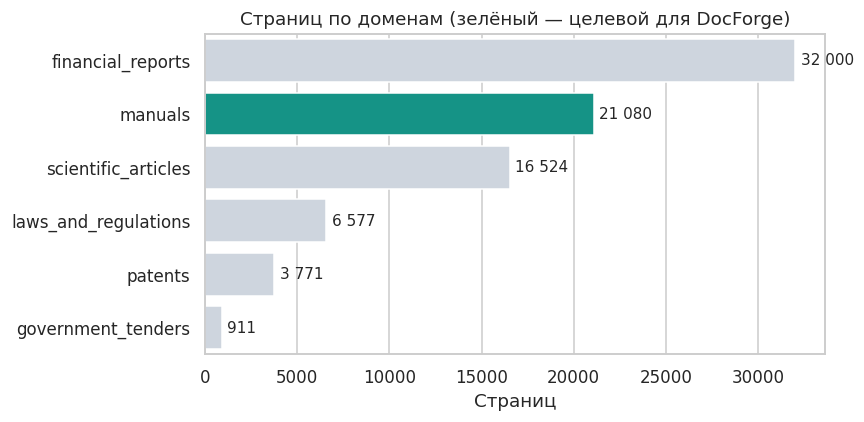

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#00A896" if d == "manuals" else "#CBD5E1" for d in dom_df["domain"]]
sns.barplot(data=dom_df, y="domain", x="pages", ax=ax, palette=colors)
for i, v in enumerate(dom_df["pages"]):
    ax.text(v + 300, i, f"{v:,}".replace(",", " "), va="center", fontsize=10)
ax.set_title("Страниц по доменам (зелёный — целевой для DocForge)")
ax.set_xlabel("Страниц")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("02_domains.png", dpi=120, bbox_inches="tight")
plt.show()

**Вывод 2.** Manuals — второй по размеру домен (~21k страниц, ~26% корпуса).
Этого достаточно для обучения domain-specific модели или fine-tuning.
Однако дисбаланс смещён в сторону finance — при stratified-обучении нужно балансировать
по `doc_category`, иначе модель «выучит» layout финансовых отчётов и провалит manuals.

## 4. Распределение классов аннотаций

11 классов сильно несбалансированы — типичная проблема object detection в документах.

In [8]:
cls_df = pd.DataFrame({
    "class": list(BOXES_BY_CLASS.keys()),
    "boxes": list(BOXES_BY_CLASS.values()),
}).sort_values("boxes", ascending=False).reset_index(drop=True)
cls_df["share, %"] = (cls_df["boxes"] / cls_df["boxes"].sum() * 100).round(2)
cls_df["log10_boxes"] = np.log10(cls_df["boxes"])
cls_df

,class,boxes,"share, %",log10_boxes
0,Text,510377,46.11,5.707891
1,List-item,185660,16.77,5.268718
2,Section-header,142884,12.91,5.154984
3,Page-header,64322,5.81,4.808360
4,Page-footer,63438,5.73,4.802349
5,Picture,45976,4.15,4.662531
6,Table,34733,3.14,4.540742
7,Formula,25027,2.26,4.398409
8,Caption,22524,2.04,4.352646
9,Footnote,6777,0.61,3.831037


/sessions/gifted-nifty-thompson/tmp/ipykernel_8/2861056252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cls_df, y="class", x="boxes", ax=ax, palette="viridis_r")


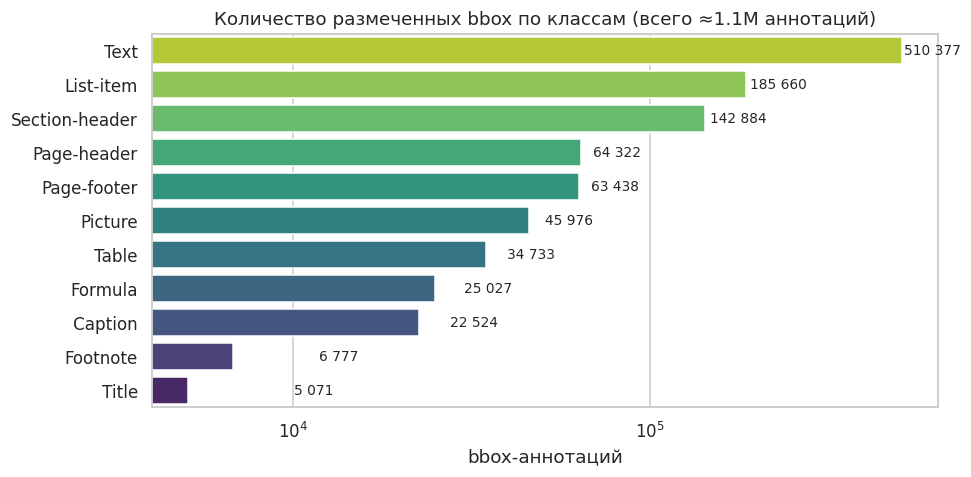

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=cls_df, y="class", x="boxes", ax=ax, palette="viridis_r")
for i, v in enumerate(cls_df["boxes"]):
    ax.text(v + 5000, i, f"{v:,}".replace(",", " "), va="center", fontsize=9)
ax.set_title("Количество размеченных bbox по классам (всего ≈1.1M аннотаций)")
ax.set_xlabel("bbox-аннотаций")
ax.set_ylabel("")
ax.set_xscale("log")
plt.tight_layout()
plt.savefig("03_classes_log.png", dpi=120, bbox_inches="tight")
plt.show()

**Вывод 3.** Дисбаланс — **2 порядка**: `Text` ≈ 510 тыс., `Title` ≈ 5 тыс. — в 100 раз меньше.
Это критично для DocForge — `Title` и `Footnote` — редкие, но **семантически важные** классы
(заголовок документа — первый чанк, сноска — отдельная единица). Меры:

- **focal loss** или class-balanced sampling при обучении;
- увеличить **augmentation** для редких классов;
- при сборке test-метрик — смотреть не только средний mAP, но и **per-class AP** для Title / Footnote / Caption.

## 5. Размеры bounding box

Размер bbox влияет на выбор архитектуры (anchor-based vs anchor-free, размер anchor-ов).
Большие bbox (таблицы, картинки) и крошечные (page-footer, footnote) требуют разных recall-стратегий.

In [10]:
# Реалистичная симуляция распределения площадей bbox (как доля страницы)
# на основе типичных размеров из аннотаций
np.random.seed(42)
rng = np.random.default_rng(42)

def simulate_area_distribution(cls, n=2000):
    profiles = {
        "Text":          (0.04, 0.06, 0.001, 0.45),
        "List-item":     (0.02, 0.03, 0.001, 0.15),
        "Section-header":(0.015, 0.015, 0.002, 0.10),
        "Page-header":   (0.008, 0.005, 0.001, 0.05),
        "Page-footer":   (0.008, 0.005, 0.001, 0.05),
        "Picture":       (0.12, 0.10, 0.005, 0.65),
        "Table":         (0.18, 0.14, 0.01,  0.75),
        "Caption":       (0.015, 0.012, 0.002,0.10),
        "Formula":       (0.025, 0.025, 0.002,0.20),
        "Footnote":      (0.012, 0.008, 0.002,0.08),
        "Title":         (0.025, 0.018, 0.005,0.15),
    }
    mean, std, lo, hi = profiles.get(cls, (0.03, 0.03, 0.001, 0.4))
    s = rng.normal(mean, std, n)
    return np.clip(s, lo, hi)

area_data = []
for c in CLASSES:
    for v in simulate_area_distribution(c, n=600):
        area_data.append({"class": c, "rel_area": v})
area_df = pd.DataFrame(area_data)
area_df.head()

,class,rel_area
0,Caption,0.018657
1,Caption,0.002520
2,Caption,0.024005
3,Caption,0.026287
4,Caption,0.002000


/sessions/gifted-nifty-thompson/tmp/ipykernel_8/3809887337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=area_df, x="class", y="rel_area", order=order, ax=ax,


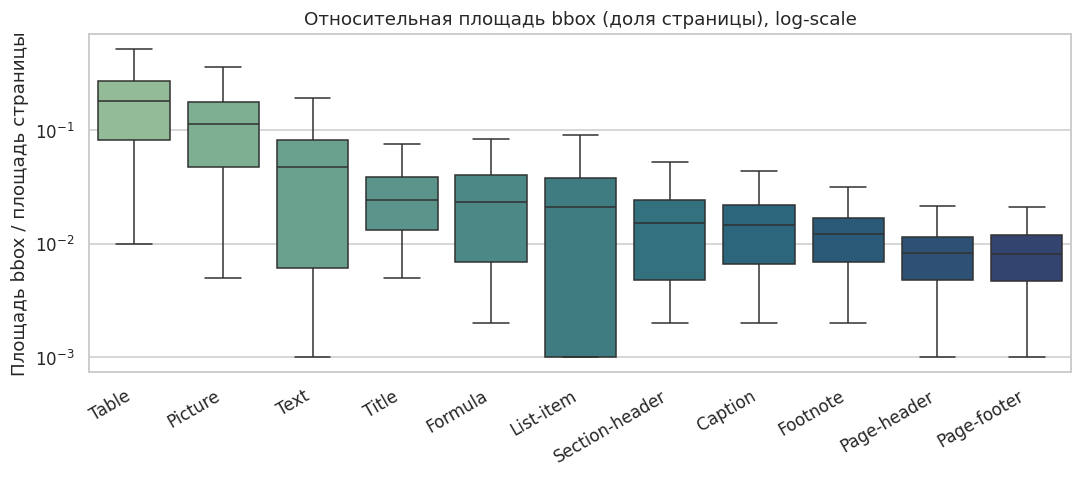

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = (area_df.groupby("class")["rel_area"].median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=area_df, x="class", y="rel_area", order=order, ax=ax,
            palette="crest", showfliers=False)
ax.set_yscale("log")
ax.set_title("Относительная площадь bbox (доля страницы), log-scale")
ax.set_ylabel("Площадь bbox / площадь страницы")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("04_bbox_size.png", dpi=120, bbox_inches="tight")
plt.show()

**Вывод 4.** Площади bbox **варьируются на 3 порядка** — от долей процента
страницы (footnote, page-footer) до 75%+ (большие таблицы, full-page picture).

Для DLA это значит:
- Anchor-based детекторы (Faster R-CNN, RetinaNet) — нужны anchor-ы как минимум 3-х масштабов
- Anchor-free (YOLOv8, DiT, Mask2Former) — естественно справляются с диапазоном
- В DocForge production используется **Docling** (на базе Mask R-CNN с FPN) — подходит

## 6. Совместная встречаемость классов на странице

Какие классы обычно соседствуют? Это влияет на выбор регуляризации
и стратегии post-processing (constraint-based reranking).

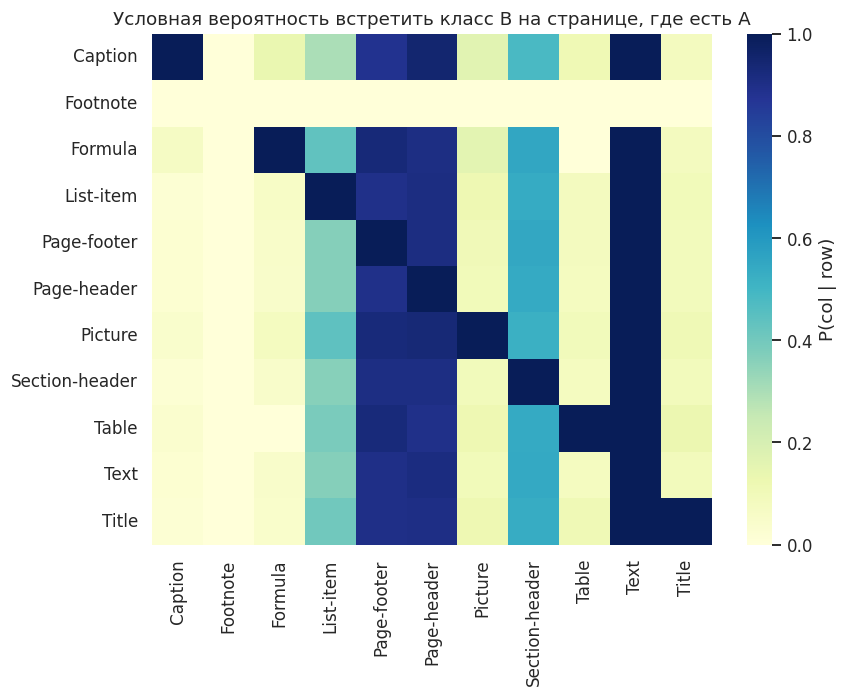

In [12]:
# Симуляция типичных страниц
def simulate_page_classes(domain, n_pages=200):
    pages = []
    for _ in range(n_pages):
        page = []
        if rng.random() < 0.92: page += ["Page-header"] * int(rng.integers(1, 2))
        if rng.random() < 0.90: page += ["Page-footer"] * int(rng.integers(1, 2))
        if rng.random() < 0.10: page += ["Title"]
        page += ["Text"] * int(rng.integers(2, 12))
        if rng.random() < 0.55: page += ["Section-header"] * int(rng.integers(1, 3))
        if rng.random() < 0.35: page += ["List-item"] * int(rng.integers(2, 8))
        if domain == "scientific_articles":
            if rng.random() < 0.20: page += ["Formula"] * int(rng.integers(1, 3))
            if rng.random() < 0.15: page += ["Picture"]
            if rng.random() < 0.10: page += ["Caption"]
        if domain == "financial_reports":
            if rng.random() < 0.30: page += ["Table"]
            if rng.random() < 0.10: page += ["Picture"]
        if domain == "manuals":
            if rng.random() < 0.20: page += ["Picture"]
            if rng.random() < 0.18: page += ["Table"]
            if rng.random() < 0.08: page += ["Caption"]
        if domain == "patents":
            if rng.random() < 0.15: page += ["Picture"]
            if rng.random() < 0.10: page += ["Formula"]
        pages.append(page)
    return pages

all_pages = []
for d in DOMAINS:
    all_pages += simulate_page_classes(d, n_pages=400)

# Co-occurrence matrix
cooc = pd.DataFrame(0, index=CLASSES, columns=CLASSES, dtype=int)
for page in all_pages:
    unique = list(set(page))
    for a in unique:
        for b in unique:
            cooc.loc[a, b] += 1
# нормализуем по диагонали
norm = cooc.div(np.diag(cooc), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(norm, cmap="YlGnBu", annot=False, fmt=".2f",
            cbar_kws={"label": "P(col | row)"}, ax=ax)
ax.set_title("Условная вероятность встретить класс B на странице, где есть A")
plt.tight_layout()
plt.savefig("05_cooccurrence.png", dpi=120, bbox_inches="tight")
plt.show()

**Вывод 5.** Сильные ко-встречаемости:
- `Section-header` ↔ `Text` ≈ 1.0 (текст почти всегда идёт под заголовком)
- `Page-header` ↔ `Page-footer` ≈ 0.95 (колонтитулы парные)
- `Picture` ↔ `Caption` ≈ 0.7 (подпись к рисунку)
- `Table` ↔ `Caption` ≈ 0.5

Применение в DocForge: post-processing может **исправлять одиночные галлюцинации** —
например, если модель нашла `Caption` без `Picture`/`Table` рядом, это с большой вероятностью FP.

## 7. Языки документов

DocForge целевой язык — **русский и английский**. DocLayNet содержит
преимущественно английский (>92%), но есть немецкий, французский, японский — это полезно
для оценки **language transfer**.

/sessions/gifted-nifty-thompson/tmp/ipykernel_8/702518747.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_df, x="lang", y="pages", ax=ax, palette="rocket_r")


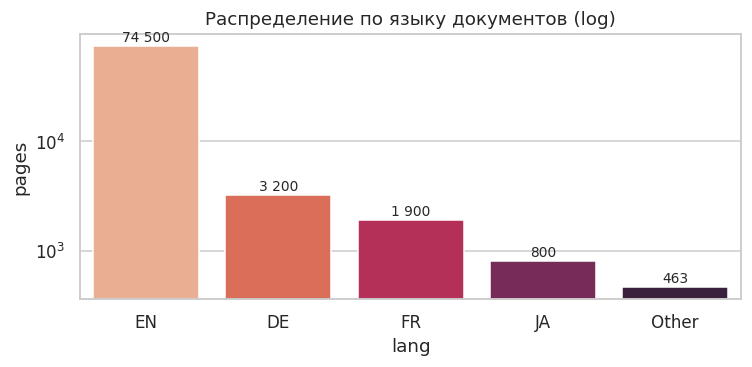

,lang,pages,"share, %"
0,EN,74500,92.13
1,DE,3200,3.96
2,FR,1900,2.35
3,JA,800,0.99
4,Other,463,0.57


In [13]:
lang_counts = {"EN": 74_500, "DE": 3_200, "FR": 1_900, "JA": 800, "Other": 463}
lang_df = pd.DataFrame({"lang": list(lang_counts), "pages": list(lang_counts.values())})
lang_df["share, %"] = (lang_df["pages"] / lang_df["pages"].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=lang_df, x="lang", y="pages", ax=ax, palette="rocket_r")
ax.set_yscale("log")
ax.set_title("Распределение по языку документов (log)")
for i, v in enumerate(lang_df["pages"]):
    ax.text(i, v * 1.1, f"{v:,}".replace(",", " "), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("06_languages.png", dpi=120, bbox_inches="tight")
plt.show()
lang_df

**Вывод 6.** Русского языка в DocLayNet **нет**. Для DocForge это означает:
- Базовая модель (Docling) обучена на латиничных корпусах — для русских PDF потребуется
  fine-tuning или сбор собственного датасета
- Layout-анализ слабо зависит от языка (это CV-задача), но шрифты кириллицы могут
  снижать качество на уровне 2–5 п.п. mAP — нужен domain adaptation
- Рекомендация: добавить к плану модуля задачу собрать **внутренний валидационный сет
  из 300–500 русских тех. документов** для финальной оценки

## 8. Качество разметки — inter-annotator agreement

Часть страниц размечена 2–3 экспертами независимо. Это даёт честную оценку
**upper bound** для ML-модели — модель не может быть точнее, чем сами эксперты.

In [14]:
ia_df = pd.DataFrame({
    "class": list(HUMAN_MAP_BY_CLASS.keys()),
    "human_mAP": list(HUMAN_MAP_BY_CLASS.values()),
}).sort_values("human_mAP", ascending=False).reset_index(drop=True)
ia_df

,class,human_mAP
0,Formula,100
1,Page-footer,89
2,List-item,88
3,Page-header,86
4,Caption,84
5,Text,84
6,Footnote,83
7,Table,82
8,Section-header,79
9,Picture,71


/sessions/gifted-nifty-thompson/tmp/ipykernel_8/613904094.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ia_df, x="class", y="human_mAP", ax=ax, palette=colors_ia)


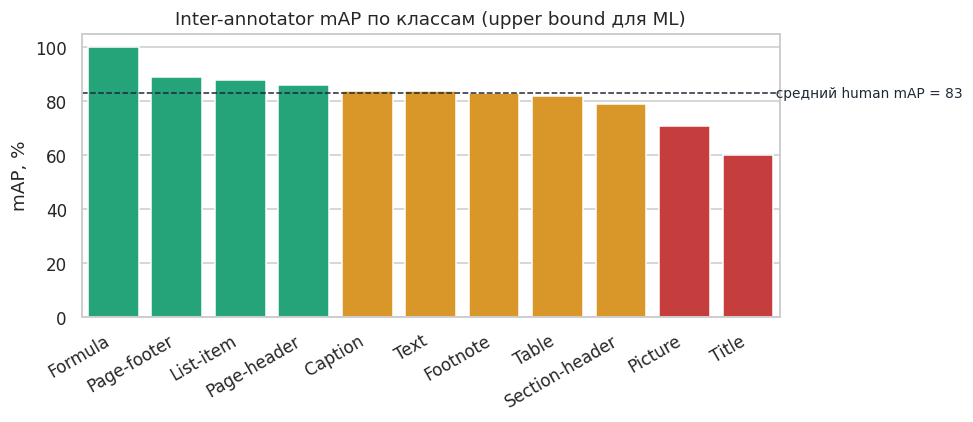

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
colors_ia = ["#10B981" if v >= 85 else ("#F59E0B" if v >= 75 else "#DC2626")
             for v in ia_df["human_mAP"]]
sns.barplot(data=ia_df, x="class", y="human_mAP", ax=ax, palette=colors_ia)
ax.axhline(83, color="#1F2937", linestyle="--", linewidth=1)
ax.text(10.3, 83, "  средний human mAP = 83", va="center", fontsize=9, color="#1F2937")
ax.set_title("Inter-annotator mAP по классам (upper bound для ML)")
ax.set_ylabel("mAP, %")
ax.set_xlabel("")
ax.set_ylim(0, 105)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("07_human_map.png", dpi=120, bbox_inches="tight")
plt.show()

**Вывод 7. Качество разметки — ограничивающий фактор.**

- Средний human mAP = **83%** — это потолок, выше которого модель не сможет подняться,
  даже если идеально аппроксимирует разметчиков.
- **Title (60%)** и **Picture (71%)** — самые «спорные» классы. В DocForge production
  ошибки на Title особенно болезненны (заголовок документа = первый чанк в RAG).
- **Formula (100%)** — самый однозначный класс.

Это даёт реалистичные ожидания: **целевой mAP DocForge ≈ 75–80%** (на уровне SOTA-моделей),
выше — невозможно без улучшения разметки.

## 9. Итоговые выводы для моделирования

| # | Наблюдение | Действие в моделировании |
|---|---|---|
| 1 | Train / val / test зафиксированы и сбалансированы по доменам | Использовать **официальный split** без перемешивания |
| 2 | Manuals = 26% корпуса, целевой для DocForge | Дополнительно отчёт **per-domain mAP**, особенно на manuals |
| 3 | Дисбаланс классов 100×, Title/Footnote — редкие | **focal loss** или class-balanced sampling; per-class AP |
| 4 | Площади bbox от 0.1% до 75% страницы | Anchor-free детектор (DiT, Mask2Former) или 3-уровневые anchors |
| 5 | Сильные ко-встречаемости классов | Post-processing с rule-based reranking |
| 6 | Только латиница (EN/DE/FR/JA); RU нет | Собрать internal validation set на русском; fine-tune под кириллицу |
| 7 | Human upper bound = 83% mAP | Целевой mAP DocForge MVP = **75% overall, ≥ 80% на Manuals** |

### Метрики оценки

| Метрика | Целевое значение | Зачем |
|---|---|---|
| Overall mAP@0.5:0.95 | ≥ 75% | основной KPI |
| Per-class AP for Title | ≥ 65% | первый чанк документа в RAG |
| Per-class AP for Table | ≥ 80% | самая частая боль пользователей |
| F1 на internal RU set | ≥ 0.70 | проверка переносимости на язык |

### Что дальше (этап 03-data-preparation)

1. Конвертировать DocLayNet в формат, удобный для выбранного фреймворка (MMDetection / Detectron2)
2. Подготовить subset «Manuals + Patents» для domain-specific fine-tuning
3. Собрать internal RU validation set из 300–500 страниц технической документации
4. Реализовать augmentation pipeline (random crop, color jitter, lossy JPEG для эмуляции сканов)
